## Importar e carregar dados

In [24]:
import pandas as pd
import os

def load_dataset():
    return pd.read_csv("../data/raw/games.csv")

df = load_dataset()

print(df.shape)
df.head()

(122611, 39)


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [26]:
df = df.dropna(subset=["Price", "Positive", "Negative"])

print(df.shape)

(122611, 39)


## Configurar dataset

In [27]:
df["target"] = (df["Positive"] > df["Negative"]).astype(int)

In [28]:
df_model = df[["Price", "Positive", "target"]]
df_model.head()

,Price,Positive,target
2539430,0,0,0
496350,65,252,1
1034400,0,21,1
3292190,0,0,0
3631080,0,0,0


In [29]:
df_model = df_model.sample(2000)

In [30]:
dataset = []

for _, row in df_model.iterrows():
    dataset.append([
        float(row["Price"]),
        float(row["Positive"]),
        int(row["target"])
    ])

len(dataset)

2000

## Perceptron Manual

In [31]:
class Perceptron:
    def __init__(self, taxa=0.00000001, epocas=10):
        self.w1 = 0.0
        self.w2 = 0.0
        self.bias = 0.0
        self.taxa = taxa
        self.epocas = epocas

    def ativacao(self, x):
        return 1 if x >= 0 else 0

    def predict(self, x1, x2):
        soma = (x1 * self.w1) + (x2 * self.w2) + self.bias
        return self.ativacao(soma)

    def treinar(self, dados):
        for _ in range(self.epocas):
            for x1, x2, y in dados:
                y_pred = self.predict(x1, x2)
                erro = y - y_pred

                self.w1 += self.taxa * erro * x1
                self.w2 += self.taxa * erro * x2
                self.bias += self.taxa * erro

## Testes

In [32]:
modelo = Perceptron()

modelo.treinar(dataset)

print("Pesos finais:")
print("w1:", modelo.w1)
print("w2:", modelo.w2)
print("bias:", modelo.bias)

Pesos finais:
w1: -3.930000000000037e-06
w2: 7.942000000000356e-05
bias: -9.279999999999921e-06


In [33]:
# exemplo de jogo barato e pouco popular
print(modelo.predict(5, 50))

# exemplo de jogo caro e popular
print(modelo.predict(60, 10000))

1
1


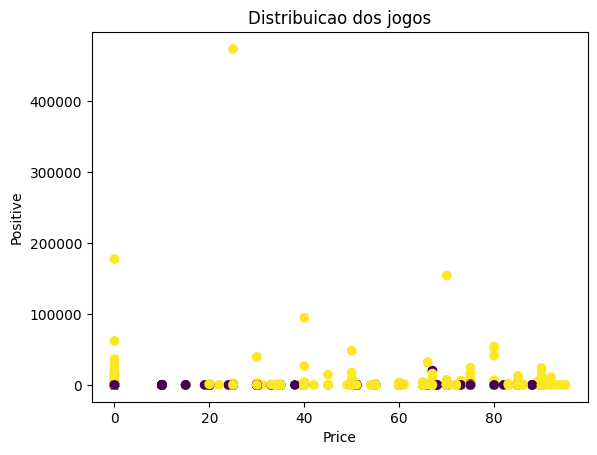

In [34]:
import matplotlib.pyplot as plt

plt.scatter(df_model["Price"], df_model["Positive"], c=df_model["target"])
plt.xlabel("Price")
plt.ylabel("Positive")
plt.title("Distribuicao dos jogos")
plt.show()